In [46]:
import pandas as pd
import seaborn as sb
import pingouin as pg
import os
import scipy.stats as stats
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.style.use('/Users/amonast/Documents/GitHub/Amy_Reviews/paper_style.mplstyle')
savepath = '/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Figure4_Supp5'

In [2]:
def load_pairwise_df_all(bin_size): ### get the pairwise correlations for whole time. 
    '''
    bin_size: dataframes to load based on bin size in frame
    '''
    path=f'/Volumes/AM_SSD1/Spont2P/Analysis/correlation/pairwise_dataframes_run_equalTime/0_lag/{bin_size}_bin_overlap'
    df_pre = pd.read_csv(os.path.join(path,'pairwise_corr_df_pre.csv'),index_col=0)
    df_post = pd.read_csv(os.path.join(path, 'pairwise_corr_df_post.csv'),index_col=0)

    return df_pre,df_post

def fisher_z_transform(r):
    """
    Apply Fisher z-transform to a correlation coefficient (r).
    
    Parameters:
        r (float or ndarray): Pearson or Spearman correlation coefficient(s).
        
    Returns:
        float or ndarray: Fisher z-transformed value(s).
    """
    return 0.5 * np.log((1 + r) / (1 - r))
def change_corr_bins_rest(bins):
    '''
    bins: list or array of bin sizes
    drop any non-firing cells 

    '''
    df_all = pd.DataFrame()
    for b in bins:
        df_pre0,df_post0 = load_pairwise_df_all(b)
        # Create a mask to check where 999 appears in either df_pre0 or df_post0
        mask_999 = (df_pre0 == 999) | (df_post0 == 999)
        # Get the indices of the rows with 999 in either dataframe
        rows_with_999 = mask_999.any(axis=1)
        # Remove these rows from df_cleaned
        df_post= df_post0[~rows_with_999]
        df_pre= df_pre0[~rows_with_999]
        abs_change = np.abs(df_post['Spearmans R']-df_pre['Spearmans R'])
        change = df_post['Spearmans R']-df_pre['Spearmans R']
        Z_change =df_post['ZScored Spearmans R']-df_pre['ZScored Spearmans R']
        Z_abs=np.abs(df_post['ZScored Spearmans R']-df_pre['ZScored Spearmans R'])
        df = df_pre.copy()
        df = df.drop(['Session','ZScored Spearmans R','pvals'],axis=1)
        df['deltaR(abs)'] = abs_change
        df['deltaR']=change
        df['deltaZScored']=Z_change
        df['absZ']=Z_abs
        df['Bin Size']=b*1/30
        df_all=pd.concat([df_all,df],ignore_index=False)
    return df_all

def zscore_change_rest(df_change):
    '''
    drop any non-firing cells 
    '''
    bins = np.unique(df_change['Bin Size'])
    zscored_all=[]
    zscored_persession=[]
    zabs_all=[]
    for b in bins: #within bin sizes
        df_b = df_change.loc[df_change['Bin Size']==b]
        zscored=[]
        fisherz=[]
        zscored_session=[]
        zabs=[]
        for ani in df_b.Animal.unique(): #within each animal
            df_a = df_b.loc[df_b.Animal==ani]
            zscored.extend(stats.zscore(df_a['deltaR'])) #ZScore the change in coefficient
            zscored_session.extend(df_a['deltaZScored'])
            fisherz.extend(fisher_z_transform(df_a['deltaR']))
            zabs.extend(df_a['absZ'])
        zscored_all.extend(zscored)
        zscored_persession.extend(zscored_session)
        zabs_all.extend(zabs)
    df_change.drop(['deltaZScored','absZ'],axis=1,inplace=True)
    df_change['deltaR_Zscore']=zscored_all
    df_change['ZScored deltaR Session']=zscored_persession
    df_change['|deltaR|']=zabs_all
    return df_change

In [3]:
bins = [4,8,10,16,20,25,40, 50, 80, 100, 125]
df_all=pd.DataFrame()
for b in bins:
    df_pre,df_post = load_pairwise_df_all(b)
    df = pd.concat([df_pre,df_post],ignore_index=True)
    df['Bin Size (s)'] = np.round(b*1/30,decimals=3)
    df_all = pd.concat([df_all,df],ignore_index=True)

In [4]:
df_cleaned = df_all[~df_all.eq(999).any(axis=1)]

df = df_cleaned.groupby(['Group','Animal','Session','Pair Group','Bin Size (s)']).mean().reset_index()
df['labels']=df['Pair Group'].map({'Tagged vs Tagged':'EE','Tagged vs Non-tagged':'EN','Non-tagged vs Non-tagged':'NN'})
df['session']=df['Session'].map({'Baseline':'D0','Post':'D4'})
df['FisherZ']=fisher_z_transform(df['Spearmans R'])
df_all=pd.DataFrame()
for b in bins:
    df_pre,df_post = load_pairwise_df_all(b)
    df = pd.concat([df_pre,df_post],ignore_index=True)
    df['Bin Size (s)'] = np.round(b*1/30,decimals=3)
    df_all = pd.concat([df_all,df],ignore_index=True)


In [5]:
df2=change_corr_bins_rest(bins)
df3 = zscore_change_rest(df2)
mean_change=df3.groupby(['Bin Size','Group','Animal', 'Pair Group']).mean(['deltaR(abs)','deltaR','deltaR_Zscore','ZScored deltaR Session','|deltaR|']).reset_index()
mean_change['fisherZ_all']=fisher_z_transform(mean_change['deltaR'])

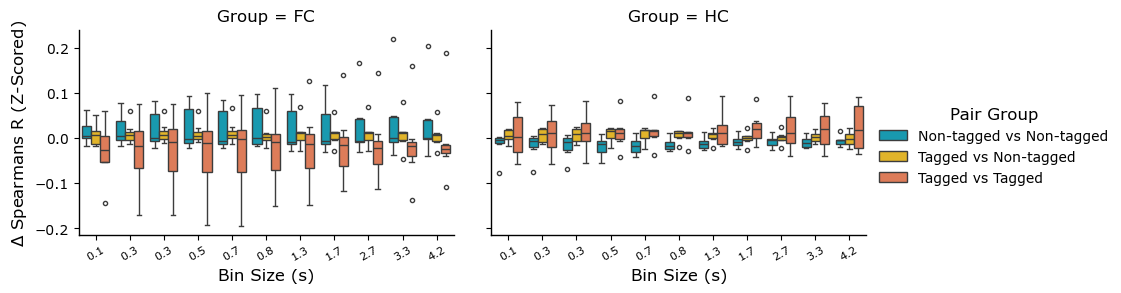

In [9]:
dv ='ZScored deltaR Session'
g=sb.catplot(data=mean_change,y=dv,x='Bin Size',col='Group',hue='Pair Group',col_order=['FC','HC'],palette=palette2,dodge=True,kind='box',height=3,aspect=1.5,legend=True,fliersize=3,flierprops={"marker": "o"},fill=True)
plt.xticks(np.arange(0,len(bins)),labels=[str(np.round(b/30,1)) for b in bins],size=8)
g.set_xticklabels(rotation=30,size=8)
#plt.tight_layout()
g.set_ylabels(r'$\Delta$ Spearmans R (Z-Scored)')
g.set_xlabels('Bin Size (s)')
plt.subplots_adjust(wspace=.1, hspace=0)
plt.savefig('Bins_boxplot_animals_run.svg',transparent=True)

# SuppFig6E plot

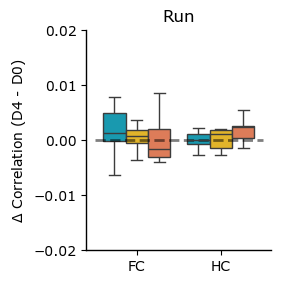

In [52]:
dv ='deltaR'

data = mean_change.loc[mean_change['Bin Size']==50/30]
fig,ax=plt.subplots(figsize=(3,3))
#sb.barplot(data=data,y=dv,x='Group',hue='Pair Group',ax=ax,palette=palette2,errorbar='se',linewidth=1,capsize=.2)
sb.boxplot(data=data,y=dv,x='Group',hue='Pair Group',ax=ax,palette=palette2,showfliers=False,legend=False)
#sb.stripplot(data=data,size=5,y=dv,x='Group',hue='Pair Group',edgecolor='#2a2d32',ax=ax,dodge=True,palette=palette2,linewidth=1,jitter=True,legend=False)
plt.hlines(0,-.5,1.5,colors='k',linestyles='dashed',linewidth=2,alpha=.5)
plt.ylabel('$\Delta$ Correlation (D4 - D0)',size=10)
plt.ylim([-0.02,.02])

# plt.legend(bbox_to_anchor=(1,1))
sb.despine()
plt.tight_layout()
plt.title('Run',size=12)
plt.xlabel('')
plt.savefig(f'{savepath}/boxplot_bin50_deltaR_run_equal.svg',transparent=True)

In [38]:
data.columns = data.columns.str.replace(' ', '_')
data['Group']=pd.Categorical(data['Group'], categories=['HC', 'FC'], ordered=False)
data['Pair_Group']=data['Pair_Group'].astype('category')
formula = 'deltaR ~ C(Group) * C(Pair_Group)'


# Fit the mixed model
model = MixedLM.from_formula(
    formula,
    data=data,
    groups=data['Animal']  # Random effect for animal identity
)
result=model.fit()
# Print the summary of the model
result.summary()

/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                             Mixed Linear Model Regression Results
===============================================================================================
Model:                           MixedLM              Dependent Variable:              deltaR  
No. Observations:                39                   Method:                          REML    
No. Groups:                      13                   Scale:                           0.0000  
Min. group size:                 3                    Log-Likelihood:                  128.9080
Max. group size:                 3                    Converged:                       Yes     
Mean group size:                 3.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.000    0.002  0.003 0.998 -0.003  0.003
C(Group)[T.FC]                                        0.002    0.002  0.764 0.445 -0.003  0.006
C(Pair_Group)[T.Tagged vs Non-tagged]                 0.000    0.002  0.094 0.925 -0.004  0.005
C(Pair_Group)[T.Tagged vs Tagged]                     0.002    0.002  0.778 0.437 -0.003  0.006
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Non-tagged] -0.001    0.003 -0.458 0.647 -0.008  0.005
C(Group)[T.FC]:C(Pair_Group)[T.Tagged vs Tagged]     -0.005    0.003 -1.560 0.119 -0.011  0.001
Group Var                                             0.000    0.001                           
===============================================================================================

"""

In [39]:
pg.normality(data,dv=dv,group='Pair_Group')

,W,pval,normal
Pair_Group,,,
Non-tagged vs Non-tagged,0.951190,0.616423,True
Tagged vs Non-tagged,0.928451,0.325243,True
Tagged vs Tagged,0.867310,0.048153,False


In [40]:
from statsmodels.regression.mixed_linear_model import MixedLM

data=mean_change.copy()
data.columns = data.columns.str.replace(' ', '_')
data['Group']=pd.Categorical(data['Group'], categories=['HC', 'FC'], ordered=False)
data['Pair_Group']=data['Pair_Group'].astype('category')
data['Bin_Size']=data['Bin_Size'].astype('category')

# Construct the formula for the model (with interaction terms)
formula = 'deltaR ~ C(Group) * C(Pair_Group) + C(Bin_Size)'

# Fit the mixed model
model = MixedLM.from_formula(
    formula,
    data=data,
    groups=data['Animal']  # Random effect for animal identity
)
result=model.fit()
# Print the summary of the model
print(result.summary())

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              deltaR   
No. Observations:               429                  Method:                          REML     
No. Groups:                     13                   Scale:                           0.0000   
Min. group size:                33                   Log-Likelihood:                  1627.3620
Max. group size:                33                   Converged:                       Yes      
Mean group size:                33.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                            -0.000    0.001 

/Users/amonast/opt/anaconda3/envs/caiman2/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [43]:
data = mean_change.loc[mean_change['Bin Size']==50/30]
dv='deltaR_Zscore'
import pingouin as pg
pg.pairwise_tests(data=data,dv=dv,between='Group',within='Pair Group',subject='Animal',parametric=False,padjust='fdr_bh')

,Contrast,Pair Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.191999
1,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.142672
2,Pair Group,-,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.028121
3,Group,-,FC,HC,False,False,21.0,NaN,two-sided,1.000000,NaN,NaN,-0.055764
4,Pair Group * Group,Non-tagged vs Non-tagged,FC,HC,False,False,29.0,NaN,two-sided,0.294872,0.442308,fdr_bh,0.783600
5,Pair Group * Group,Tagged vs Non-tagged,FC,HC,False,False,23.0,NaN,two-sided,0.835664,0.835664,fdr_bh,0.340813
6,Pair Group * Group,Tagged vs Tagged,FC,HC,False,False,7.0,NaN,two-sided,0.051282,0.153846,fdr_bh,-0.658032


In [44]:
pg.pairwise_tests(data=data,dv=dv,between='Group',within='Pair Group',subject='Animal',parametric=False,padjust='fdr_bh',within_first=False)

,Contrast,Group,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,Group,-,FC,HC,False,False,21.0,NaN,two-sided,1.000000,NaN,NaN,-0.055764
1,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.191999
2,Pair Group,-,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.142672
3,Pair Group,-,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,44.0,two-sided,0.946045,0.946045,fdr_bh,0.028121
4,Group * Pair Group,FC,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,10.0,two-sided,0.578125,0.578125,fdr_bh,0.412669
5,Group * Pair Group,FC,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,8.0,two-sided,0.375000,0.562500,fdr_bh,0.613915
6,Group * Pair Group,FC,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,7.0,two-sided,0.296875,0.562500,fdr_bh,0.410063
7,Group * Pair Group,HC,Non-tagged vs Non-tagged,Tagged vs Non-tagged,True,False,NaN,7.0,two-sided,0.562500,0.578125,fdr_bh,-0.366606
8,Group * Pair Group,HC,Non-tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,4.0,two-sided,0.218750,0.562500,fdr_bh,-1.175072
9,Group * Pair Group,HC,Tagged vs Non-tagged,Tagged vs Tagged,True,False,NaN,0.0,two-sided,0.031250,0.187500,fdr_bh,-0.905191
